In [1]:
# Import packages
import os
from pathlib import Path

os.chdir(Path.cwd().parent)
project_dir = Path("/home/mcaskey/10XvParse/")
analysis_name = "Analysis_4"

from matplotlib import pyplot as plt
from XvP_utils import plotting

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
kb_dir = project_dir / f"Data/{analysis_name}/10x/kb_python/all_out"
data = plotting.init_processing('10X', kb_dir=kb_dir, data_title = "10X")

In [4]:
def get_human_mouse_counts(data):
    data.obs["human_counts"] = data.X[:,data.var_names.str.startswith("HUMAN_")].sum(axis=1)
    data.obs["mouse_counts"] = data.X[:,data.var_names.str.startswith("MOUSE_")].sum(axis=1)
    data.obs["total_counts"] = data.obs["human_counts"] + data.obs["mouse_counts"]
    data.obs["human_fraction"] = data.obs["human_counts"] / data.obs["total_counts"]
    data.obs["species"] = "doublet"
    data.obs.loc[data.obs["human_fraction"] > 0.9, "species"] = "human"
    data.obs.loc[data.obs["human_fraction"] < 0.1, "species"] = "mouse"
    return data

data = get_human_mouse_counts(data)

6,058 cells passed the 200 UMI threshold for 10X


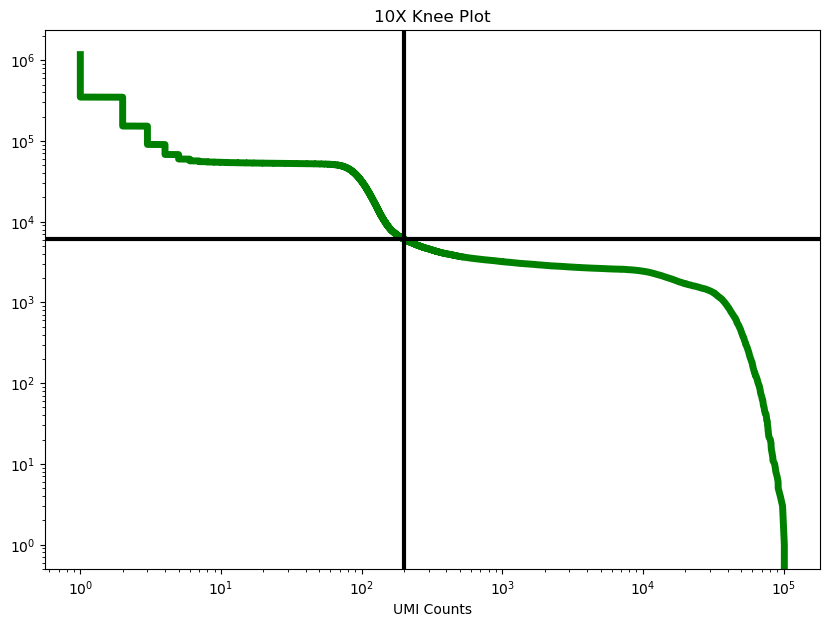

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

data_filtered = plotting.knee_plot(ax, data, cutoff = 200)
plt.show()

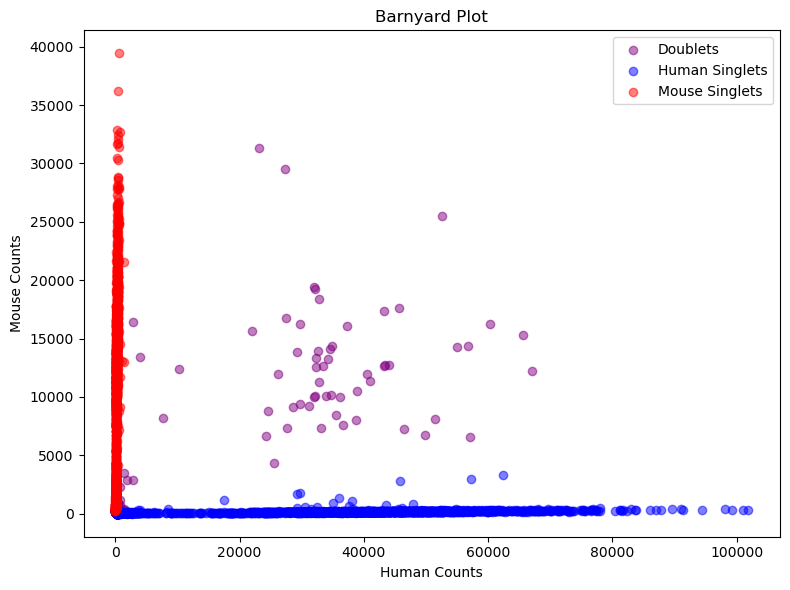

In [6]:
def barnyard_plot(ax, data):
    doublet_mask = data.obs['species'] == 'doublet'
    mouse_mask = data.obs['species'] == 'mouse'
    human_mask = data.obs['species'] == 'human'
    ax.scatter(data.obs.loc[doublet_mask, 'human_counts'], data.obs.loc[doublet_mask, 'mouse_counts'], color='purple', alpha=0.5, label='Doublets')
    ax.scatter(data.obs.loc[human_mask, 'human_counts'], data.obs.loc[human_mask, 'mouse_counts'], color='blue', alpha=0.5, label='Human Singlets')
    ax.scatter(data.obs.loc[mouse_mask, 'human_counts'], data.obs.loc[mouse_mask, 'mouse_counts'], color='red', alpha=0.5, label='Mouse Singlets')
    ax.set_xlabel("Human Counts")
    ax.set_ylabel("Mouse Counts")
    ax.set_title("Barnyard Plot")

    # ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.legend()

fig, ax = plt.subplots(figsize=(8, 6))
barnyard_plot(ax, data_filtered)
plt.tight_layout()
plt.show()